In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import contextlib
import copy
import io
import os
import queue
import threading
from concurrent.futures import ThreadPoolExecutor
from datetime import date

import cma
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, root_mean_squared_error

from aquacrop import AquaCrop, Crop, Soil, Weather
from aquacrop_slovenia import config
from aquacrop_slovenia.diagnostics import (
    kge,
    kge_alpha,
    kge_beta,
    kge_r,
    mkge,
    mkge_alpha,
    nse,
)
from aquacrop_slovenia.parameter_defaults_jablje import (
    jablje_curve_number,
    jablje_groundwater,
    jablje_initial_cond,
    jablje_maize_params,
    jablje_optimal_management,
    jablje_readily_evaporable_water,
    jablje_soil_layers,
)
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison
from aquacrop_slovenia.reading_data import (
    get_co2_for_aquacrop,
    get_station_weather,
    get_yield,
    get_yield_for_comparison,
)

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
LOCATION = "jablje"
MAX_WORKERS = os.cpu_count()

simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 12, 31),
        "planting_date": date(year, 5, 3),
        "is_seeding_year": True,
    }
    for year in range(1993, 2024)
    if year not in [2017]
]

temperatures, eto, rain = get_station_weather(8)
historical_co2 = get_co2_for_aquacrop("historical")

weather = Weather(
    location=LOCATION,
    temperatures=temperatures,
    eto_values=eto,
    rainfall_values=rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2,
)

soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} loamy sand soil",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water,
)

observed_biomass = get_yield_for_comparison(LOCATION, "biomass", "A", "N3")
observed_grain = get_yield_for_comparison(LOCATION, "grain", "A", "N3")

INTEGER_PARAMS = {name for name, val in jablje_maize_params.items() if isinstance(val, int)}

In [4]:
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.RAMDISK_DIR / f"cmaes_jablje_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

dir_queue = queue.Queue()
for d in worker_dirs:
    dir_queue.put(d)

print(f"Worker directories ready: {MAX_WORKERS}")

Worker directories ready: 28


In [5]:
# Parameter names, search bounds, and initial guess (midpoint of bounds)
param_names = [
    "harvest_index",
    "gdd_senescence",
    "gdd_maturity",
    "gdd_flowering",
    "gdd_flowering_length",
    "max_canopy_cover",
]

bounds = [
    (0.46, 0.56),   # harvest_index
    (1000, 1150),   # gdd_senescence
    (1200, 1400),   # gdd_maturity
    (480,  530),    # gdd_flowering
    (130,  170),    # gdd_flowering_length
    (0.85, 0.95),   # max_canopy_cover
]

lower = np.array([b[0] for b in bounds])
upper = np.array([b[1] for b in bounds])
x0 = (lower + upper) / 2.0

print(f"Parameters: {param_names}")
print(f"x0:         {x0}")
print(f"Bounds:     {bounds}")

Parameters: ['harvest_index', 'gdd_senescence', 'gdd_maturity', 'gdd_flowering', 'gdd_flowering_length', 'max_canopy_cover']
x0:         [5.100e-01 1.075e+03 1.300e+03 5.050e+02 1.500e+02 9.000e-01]
Bounds:     [(0.46, 0.56), (1000, 1150), (1200, 1400), (480, 530), (130, 170), (0.85, 0.95)]


In [6]:
def evaluate_params(param_values):
    """Run one candidate and return all metrics for both grain and biomass."""
    working_dir = dir_queue.get()
    try:
        params = copy.deepcopy(jablje_maize_params)
        for name, val in zip(param_names, param_values):
            params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

        crop = Crop(
            name=f"{LOCATION} maize",
            description="cma-es",
            params=params,
        )

        simulation = AquaCrop(
            simulation_periods=simulation_periods,
            crop=crop,
            soil=soil,
            management=jablje_optimal_management,
            initial_conditions=jablje_initial_cond,
            climate=weather,
            #ground_water=jablje_groundwater,
            working_dir=working_dir,
            need_daily_output=False,
            need_seasonal_output=True,
            need_harvest_output=False,
            need_evaluation_output=False,
        )

        nan_metrics = {
            f"{prefix}_{s}": np.nan
            for prefix in ("biomass", "grain")
            for s in ["rmse", "r2", "nse", "kge", "mkge", "kge_r", "kge_beta", "kge_alpha", "mkge_alpha"]
        }

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                results = simulation.run()
        except Exception:
            return nan_metrics

        seasonal = results["season"][["Year1", "BioMass", "Y(dry)"]].rename(
            columns={"Year1": "year", "BioMass": "biomass_modeled", "Y(dry)": "grain_modeled"}
        )

        def compute_metrics(observed_df, modeled_col, prefix):
            merged = observed_df.merge(seasonal[["year", modeled_col]], on="year")
            y_obs = merged["yield"].values
            y_mod = merged[modeled_col].values
            return {
                f"{prefix}_rmse":       root_mean_squared_error(y_obs, y_mod),
                f"{prefix}_r2":         r2_score(y_obs, y_mod),
                f"{prefix}_nse":        nse(y_mod, y_obs),
                f"{prefix}_kge":        kge(y_mod, y_obs),
                f"{prefix}_mkge":       mkge(y_mod, y_obs),
                f"{prefix}_kge_r":      kge_r(y_mod, y_obs),
                f"{prefix}_kge_beta":   kge_beta(y_mod, y_obs),
                f"{prefix}_kge_alpha":  kge_alpha(y_mod, y_obs),
                f"{prefix}_mkge_alpha": mkge_alpha(y_mod, y_obs),
            }

        return {
            **compute_metrics(observed_biomass, "biomass_modeled", "biomass"),
            **compute_metrics(observed_grain,   "grain_modeled",   "grain"),
        }
    finally:
        dir_queue.put(working_dir)

In [7]:
eval_log = []           # collects every evaluated candidate for post-analysis
eval_log_lock = threading.Lock()

mean_biomass = observed_biomass["yield"].mean()
mean_grain   = observed_grain["yield"].mean()
print(f"Mean observed biomass: {mean_biomass:.1f}  |  mean observed grain: {mean_grain:.1f}")


def make_objective(scalar_fn):
    """Return a function that evaluates one candidate, logs it, and returns a scalar."""
    def objective(param_values):
        r = evaluate_params(param_values)
        with eval_log_lock:
            eval_log.append({**dict(zip(param_names, param_values)), **r})
        return scalar_fn(r)
    return objective


objectives = {
    "biomass_rmse":   make_objective(lambda r: r["biomass_rmse"]),
    "grain_rmse":     make_objective(lambda r: r["grain_rmse"]),
    "combined_nrmse": make_objective(
        lambda r: r["biomass_rmse"] / mean_biomass + r["grain_rmse"] / mean_grain
    ),
}

Mean observed biomass: 18.3  |  mean observed grain: 9.4


In [ ]:

# CMA-ES settings
# sigma0: initial step size as fraction of the bounded range; 0.3 covers ~30 % of each dimension.
# The parameter space is transformed to [0, 1] internally so sigma is comparable across parameters.

SIGMA0 = 0.3   # initial step size in normalised [0,1] space

# Set popsize >= MAX_WORKERS so every core gets work each generation.
# The default (4 + floor(3*ln(n)) ≈ 9 for n=6) is often smaller than core count.
default_popsize = 4 + int(3 * np.log(len(param_names)))
POPSIZE = max(MAX_WORKERS, default_popsize)

CMAES_OPTIONS = {
    "bounds": [lower.tolist(), upper.tolist()],
    "popsize": POPSIZE,
    "maxiter": 300,
    "tolx": 1e-5,
    "tolfun": 1e-5,
    "seed": 42,
    "verbose": 3,
}

print(f"Cores: {MAX_WORKERS}  |  default popsize: {default_popsize}  |  using popsize: {POPSIZE}")
print(f"Options: {CMAES_OPTIONS}")


In [25]:
def parallel_evaluate(objective_fn, solutions):
    """Evaluate a list of candidate solutions in parallel using ThreadPoolExecutor."""
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        return list(executor.map(objective_fn, solutions))

In [26]:
def run_cmaes(objective_name):
    """Run CMA-ES for a given objective and return the CMAEvolutionStrategy object."""
    objective_fn = objectives[objective_name]
    es = cma.CMAEvolutionStrategy(x0, SIGMA0, CMAES_OPTIONS)

    while not es.stop():
        solutions = es.ask()
        fitnesses = parallel_evaluate(objective_fn, solutions)
        # Replace NaN (failed simulations) with a large penalty
        penalty = max((f for f in fitnesses if np.isfinite(f)), default=1e6) * 10
        fitnesses = [penalty if not np.isfinite(f) else f for f in fitnesses]
        es.tell(solutions, fitnesses)
        es.disp()

    es.result_pretty()
    return es

In [27]:
eval_log.clear()
print("=== Optimising for BIOMASS RMSE ===")
es_biomass = run_cmaes("biomass_rmse")
print(f"\nBest biomass RMSE: {es_biomass.result.fbest:.4f}")
print("Best parameters:")
for name, val in zip(param_names, es_biomass.result.xbest):
    print(f"  {name}: {val:.4f}")

C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\cma\evolution_strategy.py:1541: UserWarning: Sampling standard deviation i=0 (and 1 others) at iteration 0 multiplied by 0.11111111111111113 to stds[0]=0.03333333333333334
  warnings.warn("Sampling standard deviation i={0}{4} at iteration {1}"


In [28]:
eval_log.clear()
print("=== Optimising for GRAIN RMSE ===")
es_grain = run_cmaes("grain_rmse")
print(f"\nBest grain RMSE: {es_grain.result.fbest:.4f}")
print("Best parameters:")
for name, val in zip(param_names, es_grain.result.xbest):
    print(f"  {name}: {val:.4f}")

C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\cma\evolution_strategy.py:1541: UserWarning: Sampling standard deviation i=0 (and 1 others) at iteration 0 multiplied by 0.11111111111111113 to stds[0]=0.03333333333333334
  warnings.warn("Sampling standard deviation i={0}{4} at iteration {1}"


In [29]:
eval_log.clear()
print("=== Optimising for COMBINED normalised RMSE (biomass + grain) ===")
es_combined = run_cmaes("combined_nrmse")
print(f"\nBest combined nRMSE: {es_combined.result.fbest:.6f}")
print("Best parameters:")
for name, val in zip(param_names, es_combined.result.xbest):
    print(f"  {name}: {val:.4f}")

C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\cma\evolution_strategy.py:1541: UserWarning: Sampling standard deviation i=0 (and 1 others) at iteration 0 multiplied by 0.11111111111111113 to stds[0]=0.03333333333333334
  warnings.warn("Sampling standard deviation i={0}{4} at iteration {1}"


In [30]:
# Re-evaluate each best solution to get the full metric set
cmaes_runs = {
    "biomass_rmse":   es_biomass.result.xbest,
    "grain_rmse":     es_grain.result.xbest,
    "combined_nrmse": es_combined.result.xbest,
}

summary_rows = []
for run_name, x in cmaes_runs.items():
    metrics = evaluate_params(x)
    row = {"optimised_for": run_name, **dict(zip(param_names, x)), **metrics}
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("optimised_for")
summary_df

,harvest_index,gdd_senescence,gdd_maturity,gdd_flowering,gdd_flowering_length,max_canopy_cover,biomass_rmse,biomass_r2,biomass_nse,biomass_kge,...,biomass_mkge_alpha,grain_rmse,grain_r2,grain_nse,grain_kge,grain_mkge,grain_kge_r,grain_kge_beta,grain_kge_alpha,grain_mkge_alpha
optimised_for,,,,,,,,,,,,,,,,,,,,,
biomass_rmse,0.462244,1000.202877,1208.357020,480.261867,138.773183,0.850431,4.690117,-0.166766,-0.166766,-0.058600,...,0.362123,2.478429,-0.458854,-0.458854,0.036909,0.079908,0.235754,0.849741,0.433524,0.510184
grain_rmse,0.476294,1075.332981,1299.995323,505.508582,150.120540,0.918567,5.880342,-0.834094,-0.834094,-0.051138,...,0.457603,2.124693,-0.072139,-0.072139,0.065996,0.069933,0.196977,0.985389,0.523236,0.530995
combined_nrmse,0.510357,1037.077072,1294.165251,520.464149,130.825296,0.850014,5.221172,-0.445947,-0.445947,-0.059179,...,0.417996,2.058993,-0.006859,-0.006859,0.075193,0.075872,0.233962,0.997490,0.481882,0.483094


In [31]:
display_cols = [
    "biomass_rmse", "biomass_r2", "biomass_nse", "biomass_kge", "biomass_mkge",
    "grain_rmse",   "grain_r2",   "grain_nse",   "grain_kge",   "grain_mkge",
]
print("Metric comparison across optimisation targets:")
summary_df[display_cols].round(4)

,biomass_rmse,biomass_r2,biomass_nse,biomass_kge,biomass_mkge,grain_rmse,grain_r2,grain_nse,grain_kge,grain_mkge
optimised_for,,,,,,,,,,
biomass_rmse,4.6901,-0.1668,-0.1668,-0.0586,-0.0761,2.4784,-0.4589,-0.4589,0.0369,0.0799
grain_rmse,5.8803,-0.8341,-0.8341,-0.0511,-0.0910,2.1247,-0.0721,-0.0721,0.0660,0.0699
combined_nrmse,5.2212,-0.4459,-0.4459,-0.0592,-0.0877,2.0590,-0.0069,-0.0069,0.0752,0.0759


In [32]:
# Convergence info from each run
for name, es in [("biomass_rmse", es_biomass), ("grain_rmse", es_grain), ("combined_nrmse", es_combined)]:
    r = es.result
    print(f"{name}: evaluations={r.evaluations}, iterations={r.iterations}, stop={es.stop()}")

In [33]:
# All evaluated candidates from the last CMA-ES run (combined)
all_evals_df = pd.DataFrame(eval_log)
print(f"Total evaluations stored from last run: {len(all_evals_df)}")
all_evals_df.sort_values("biomass_rmse").head(10)

,harvest_index,gdd_senescence,gdd_maturity,gdd_flowering,gdd_flowering_length,max_canopy_cover,biomass_rmse,biomass_r2,biomass_nse,biomass_kge,...,biomass_mkge_alpha,grain_rmse,grain_r2,grain_nse,grain_kge,grain_mkge,grain_kge_r,grain_kge_beta,grain_kge_alpha,grain_mkge_alpha
446,0.515956,1038.817155,1293.733112,515.910424,130.789832,0.850143,5.209757,-0.439632,-0.439632,-0.058345,...,0.419974,2.082466,-0.029946,-0.029946,0.076800,0.073161,0.223977,1.013556,0.500098,0.493409
431,0.512907,1039.872367,1291.666079,517.292230,130.685159,0.851403,5.219036,-0.444765,-0.444765,-0.057715,...,0.420656,2.071018,-0.018654,-0.018654,0.070796,0.071757,0.224904,0.996435,0.487522,0.489266
438,0.530900,1039.286489,1290.837465,518.725033,130.350160,0.853648,5.221117,-0.445917,-0.445917,-0.059486,...,0.419416,2.105416,-0.052772,-0.052772,0.082967,0.073433,0.227831,1.035783,0.506620,0.489117
442,0.510357,1037.077072,1294.165251,520.464149,130.825296,0.850014,5.221172,-0.445947,-0.445947,-0.059179,...,0.417996,2.058993,-0.006859,-0.006859,0.075193,0.075872,0.233962,0.997490,0.481882,0.483094
430,0.486282,1044.508899,1295.707388,514.116161,132.606120,0.852954,5.235512,-0.453901,-0.453901,-0.058222,...,0.425778,2.104531,-0.051888,-0.051888,0.063954,0.075881,0.225380,0.956563,0.476302,0.497931
432,0.529020,1044.877782,1291.392706,515.458077,133.140356,0.850615,5.237786,-0.455164,-0.455164,-0.057453,...,0.425541,2.110992,-0.058356,-0.058356,0.086065,0.076676,0.226099,1.035110,0.515105,0.497633
439,0.503625,1045.612241,1294.343080,512.707503,134.357797,0.851959,5.238608,-0.455621,-0.455621,-0.057646,...,0.426443,2.086095,-0.033539,-0.033539,0.069228,0.075771,0.222509,0.976017,0.488856,0.500868
419,0.496339,1046.498575,1295.411443,512.665619,134.398600,0.852819,5.240283,-0.456552,-0.456552,-0.057888,...,0.426665,2.086996,-0.034432,-0.034432,0.068505,0.075028,0.221587,0.976070,0.488939,0.500926
434,0.516805,1045.484372,1297.847429,514.731614,133.316488,0.850000,5.241646,-0.457310,-0.457310,-0.057326,...,0.426327,2.086462,-0.033903,-0.033903,0.080815,0.076573,0.224823,1.015755,0.506287,0.498434
429,0.473868,1046.108795,1295.311199,512.589343,134.748995,0.852941,5.246527,-0.460025,-0.460025,-0.057048,...,0.427203,2.200281,-0.149781,-0.149781,0.047954,0.070580,0.220225,0.918216,0.459950,0.500917


In [34]:
output_path = config.RESULTS_DIR / "cmaes_jablje_summary.pkl"
summary_df.reset_index().to_pickle(output_path)
print(f"Saved summary ({len(summary_df)} rows) to {output_path}")

In [35]:
def rerun_best(param_values, label):
    """Re-run a full simulation with given params and return seasonal results."""
    params = copy.deepcopy(jablje_maize_params)
    for name, val in zip(param_names, param_values):
        params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

    best_dir = config.RAMDISK_DIR / f"cmaes_jablje_best_{label}"
    best_dir.mkdir(parents=True, exist_ok=True)

    sim = AquaCrop(
        simulation_periods=simulation_periods,
        crop=Crop(name=f"{LOCATION} maize ({label})", description=label, params=params),
        soil=soil,
        management=jablje_optimal_management,
        initial_conditions=jablje_initial_cond,
        climate=weather,
        #ground_water=jablje_groundwater,
        working_dir=best_dir,
        need_daily_output=False,
        need_seasonal_output=True,
        need_harvest_output=False,
        need_evaluation_output=False,
    )
    return sim.run()["season"]

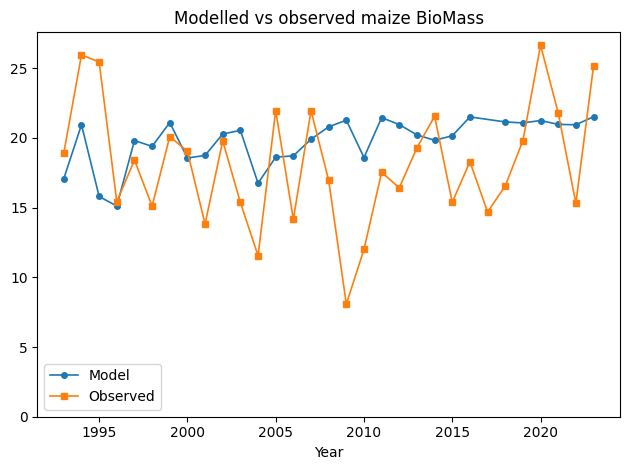

In [36]:
seasonal_biomass_opt = rerun_best(es_biomass.result.xbest, "biomass_opt")
print("=== Best solution optimised for biomass RMSE ===")
plot_yield_timeseries_comparison(seasonal_biomass_opt, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass")

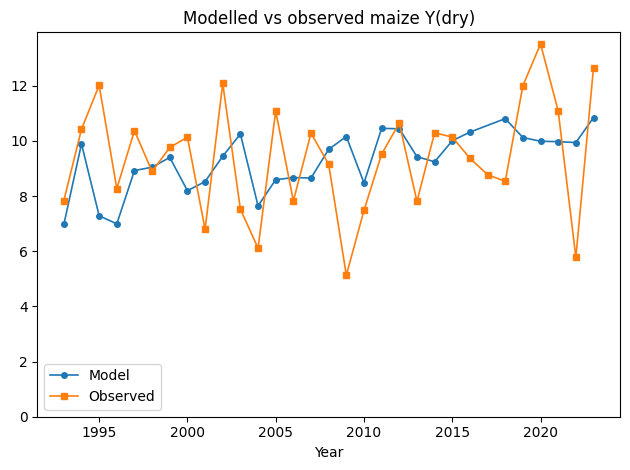

In [37]:
seasonal_grain_opt = rerun_best(es_grain.result.xbest, "grain_opt")
print("=== Best solution optimised for grain RMSE ===")
plot_yield_timeseries_comparison(seasonal_grain_opt, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)")

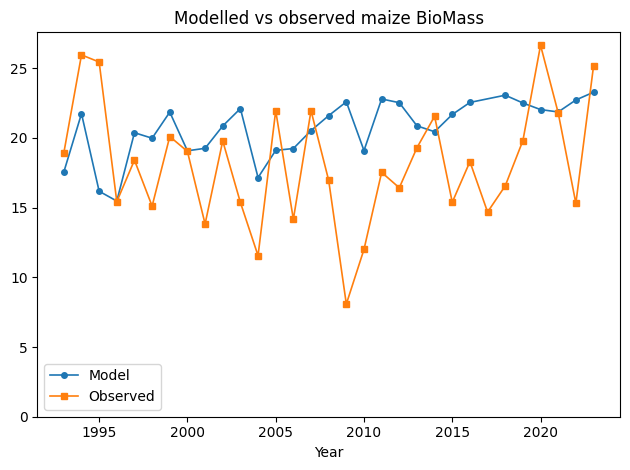

In [38]:
seasonal_combined_opt = rerun_best(es_combined.result.xbest, "combined_opt")
print("=== Best solution optimised for combined nRMSE ===")
plot_yield_timeseries_comparison(seasonal_combined_opt, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass")

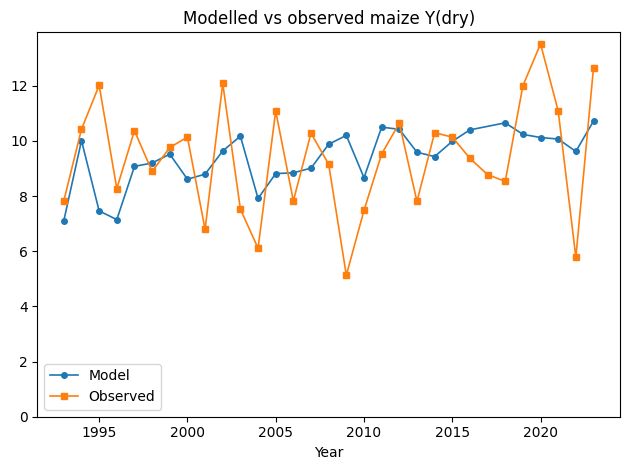

In [39]:
plot_yield_timeseries_comparison(seasonal_combined_opt, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)")